In [1]:
import slangpy as spy
from itertools import islice
from pyglm import glm
import torch
import torchvision
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt

from cs248a_renderer import setup_device, RendererModules
from cs248a_renderer.renderer.core_renderer import Renderer
from cs248a_renderer.model.volumes import DenseVolume
from cs248a_renderer.model.transforms import Transform3D

from cs231nfinal.camera import RandomCameraTransform
from cs231nfinal.tvnorm import tv_image_loss_isotropic, tv_volume_loss_isotropic
# from cs231nfinal.style import StylizerArgs, AespaStylizer, NaiveStylizer, InjectionStylizer, InjectionStylizer2, GatysStylizer

%load_ext autoreload
%autoreload 2

device = setup_device([])
renderer_modules = RendererModules(device)

[WARN] No supported shader model found, pretending to support sm_6_0.


In [2]:
# OUTPUT_IMG_SIZE = (800, 800)
# PROCESS_IMG_SIZE = (256, 256)
PROCESS_IMG_SIZE = (384, 384)
# PROCESS_IMG_SIZE = (512, 512)
PREVIEW_IMG_SIZE = (512, 512)

# create framebuffers
output_image = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.r32_float,
    usage=spy.TextureUsage.unordered_access,
    width=PROCESS_IMG_SIZE[0],
    height=PROCESS_IMG_SIZE[1],
)

output_preview = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.r32_float,
    usage=spy.TextureUsage.unordered_access,
    width=PREVIEW_IMG_SIZE[0],
    height=PREVIEW_IMG_SIZE[1],
)

# output_mask = device.create_texture(
#     type=spy.TextureType.texture_2d,
#     format=spy.Format.r32_float,
#     usage=spy.TextureUsage.unordered_access,
#     width=PROCESS_IMG_SIZE[0],
#     height=PROCESS_IMG_SIZE[1],
# )
# Setup the renderer
renderer = Renderer(
    device=device,
    render_texture=output_image,
    render_modules=renderer_modules
)
renderer.sqrt_spp = 1
renderer._ambientColor = glm.vec4(1.0, 1.0, 1.0, 1.0)

preview_renderer = Renderer(
    device=device,
    render_texture=output_preview,
    render_modules=renderer_modules
)
preview_renderer.sqrt_spp = 1
preview_renderer._ambientColor = glm.vec4(1.0, 1.0, 1.0, 1.0)

# mask_renderer = Renderer(
#     device=device,
#     render_texture=output_mask,
#     render_modules=renderer_modules
# )
# mask_renderer.sqrt_spp = 1
# mask_renderer._ambientColor = glm.vec4(1.0, 1.0, 1.0, 1.0)

In [3]:
from cs231nfinal.data import DatasetID, DataSet
import numpy as np
from openvdb import FloatGrid, read as vdbread

dataset = DataSet.Get(DatasetID.SMOKE_MIDRES)

# data_array = np.zeros(dataset.resolution)
grid = dataset.get_grid("density", frame=70, type=FloatGrid)
grid_min, grid_max = grid.evalActiveVoxelBoundingBox()
data_array = np.zeros(np.array(grid_max) - np.array(grid_min))

grid.copyToArray(data_array, ijk=(0,0,0))
min, max = grid.evalMinMax()

# grid = dataset.get_grid("density", frame=70, type=FloatGrid)
# grid = vdbread("data/fire/fire.70.vdb", "density")
# grid_min, grid_max = grid.evalActiveVoxelBoundingBox()
# data_array = np.zeros(np.array(grid_max) - np.array(grid_min))

# grid.copyToArray(data_array, ijk=(0,0,0))
# min, max = grid.evalMinMax()
# data_array = ((data_array + min) / (max - min))

# normalize data
data_array = 0.5 * ((data_array + min) / (max - min))

In [4]:
def make_dense_volume(volume_tensor) -> DenseVolume:
    return DenseVolume(
        name="volume",
        # transform=Transform3D(rotation=glm.quatLookAt((0, -1, 0), (0, 0, 1))),
        transform=Transform3D(),
        data=volume_tensor.detach().numpy().astype(np.float32),
        properties={
            "pivot": (0.5, 0.5, 0.5),
            "voxel_size": dataset.voxel_size,
            # "voxel_size": 0.03,
        },
    )

def show_preview(dense_volume, cam_mat, fov, cache=None):
    preview_renderer.load_volume(volume=dense_volume)
    preview_renderer.render(cam_mat, fov)
    preview_res = np.flipud(output_preview.to_numpy().copy())
    if cache is not None:
        cache[0] = preview_res
    else:
        plt.imshow(preview_res, cmap="gray")
        plt.axis("off")
        plt.show()

def ext_exp(x: torch.Tensor, c: int):
    return torch.where(x < 0, -((-x) ** (1 / c)), x ** (1 / c))

In [5]:
# stylizer = NaiveStylizer(PROCESS_IMG_SIZE, "data/style/good_ones/dark_matter_bw.png")
# stylizer = InjectionStylizer(PROCESS_IMG_SIZE, "data/style/good_ones/dark_matter_bw.png")
# stylizer = InjectionStylizer2(PROCESS_IMG_SIZE, "data/style/good_ones/dark_matter_bw.png", invert=True)
# stylizer = GatysStylizer(PROCESS_IMG_SIZE, "data/style/good_ones/dark_matter_bw.png", device="mps")

# stylizer = GatysStylizer(
#     "data/style/lame_ones/pattern1.png", 
#     sargs,
#     [1e3/n**2 for n in [64,128,256,512,512]]
# )
# good Gatys:
# params = {
#     "num_epochs": 100,
#     "num_cameras": 8,
#     "learning_rate": 5e-2,
#     # "tv_weight_2d": 0,
#     "tv_weight_3d": 0.0000,
#     # "cam_kappa": 3,
#     "cam_kappa": 0.5,
#     "cam_fov": 40,
#     "print_freq": 10,
# }

# from cs231nfinal.style import StylizerArgs
# from cs231nfinal.style.aespa import AespaStylizer

# params = {
#     "num_epochs": 120,
#     "num_cameras": 1,
#     "learning_rate": 3e-2,
#     # "tv_weight_2d": 0,
#     "tv_weight_3d": 0.0000,
#     "cam_kappa": 1000,
#     "cam_fov": 40,
#     "cam_dist": 23,
#     "print_freq": 5,
#     "print_grad": True,
# }

# sargs = StylizerArgs(resolution=PROCESS_IMG_SIZE)

# stylizer = AespaStylizer(
#     # "data/style/lame_ones/pattern1.png",
#     # "data/style/good_ones/starry.jpg",
#     "data/style/good_ones/dark_matter_bw.png",
#     sargs,
# )

torch.manual_seed(67)
from cs231nfinal.style import StylizerArgs
# from cs231nfinal.style.aespa_sds import AespaStylizerSDS
from cs231nfinal.style.aespa import AespaStylizer
# from cs231nfinal.style.gatys import GatysStylizer
# from cs231nfinal.style.naive import NaiveStylizer
# from cs231nfinal.style.styleid import InjectionStylizer2
# from cs231nfinal.style.naive_octave import NaiveStylizerOctave

params = {
    "num_epochs": 150,
    "num_cameras": 4,
    "learning_rate": 1e-2,
    # "tv_weight_2d": 0,
    "tv_weight_3d": 0.00000,
    "cam_kappa": 10,
    "cam_fov": 40,
    "cam_dist": 22,
    # "cam_dist": 13,
    "print_freq": 5,
    "print_grad": False,
}


# for naive:
# params = {
#     "num_epochs": 100,
#     "num_cameras": 8,
#     "learning_rate": 3e-1,
#     # "tv_weight_2d": 0,
#     "tv_weight_3d": 10,
#     "cam_kappa": 5,
#     "cam_fov": 40,
#     "cam_dist": 23,
#     "print_freq": 10,
#     "print_grad": False,
# }

sargs = StylizerArgs(
    resolution=PROCESS_IMG_SIZE,
    style_path="data/style/good_ones/oil_crop.jpg",
    # style_path="data/style/good_ones/dark_matter_bw.png",
    # style_path="data/style/good_ones/blue_strokes.jpg",
    # style_path="data/style/good_ones/fire.png",
    # style_path="data/style/good_ones/volcano.png",
    # style_path="data/style/lame_ones/pattern1.png",
)

# stylizer = InjectionStylizer2(sargs)
# stylizer = NaiveStylizer(sargs, k=params["num_cameras"])
stylizer = AespaStylizer(sargs)
# stylizer = GatysStylizer(sargs)
# stylizer = AespaStylizerSDS(sargs, k=params["num_cameras"], crop=(500,500))
# stylizer = NaiveStylizerOctave(sargs,k=params["num_cameras"])

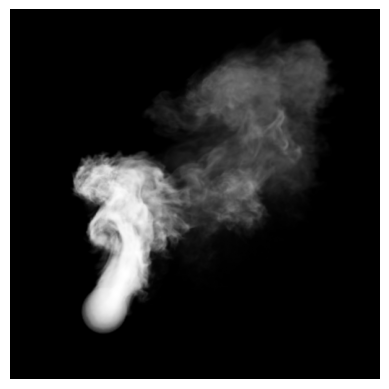

In [6]:
cam_transform = RandomCameraTransform(params["cam_dist"], kappa=params["cam_kappa"])
canonical_cam = next(RandomCameraTransform(params["cam_dist"], kappa=np.inf))

grid.copyToArray(data_array, ijk=grid.evalLeafBoundingBox()[0])
min, max = grid.evalMinMax()

# normalize data
data_array = 0.5 * ((data_array + min) / (max - min))
original_tensor = torch.tensor(data_array.astype(np.float32))
# input_tensor = torch.tensor(data_array.astype(np.float32), requires_grad=True)
original_density_total = original_tensor.sum()

dense_volume = make_dense_volume(original_tensor)

show_preview(dense_volume, canonical_cam, params["cam_fov"])


Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

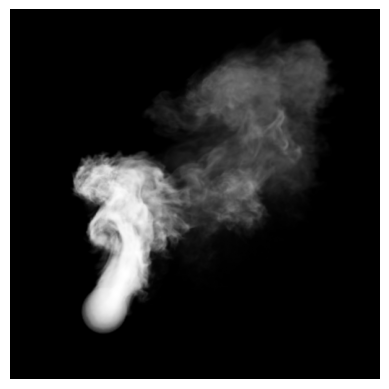

/Users/milner/Documents/VSCode/CS231N/final-project/external/aespa/AesPA_Net/utils.py:143: UserWarning: This overload of baddbmm is deprecated:
	baddbmm(Number beta, Tensor input, Number alpha, Tensor batch1, Tensor batch2, *, Tensor out = None)
Consider using one of the following signatures instead:
	baddbmm(Tensor input, Tensor batch1, Tensor batch2, *, Number beta = 1, Number alpha = 1, Tensor out = None)
	baddbmm(Tensor input, Tensor batch1, Tensor batch2, torch.dtype out_dtype, *, Number beta = 1, Number alpha = 1, Tensor out = None) (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/python_arg_parser.cpp:1870.)
  P = torch.baddbmm(1.5, P, -0.5, torch.matrix_power(P, 3), cov_N)


tensor(17.4971, device='mps:0', grad_fn=<AddBackward0>) tensor(0., grad_fn=<MseLossBackward0>)
[WARN] (rhi) slang: metal 32023.850: /Users/milner/Documents/VSCode/CS231N/final-project/.venv/lib/python3.13/site-packages/cs248a_renderer/slang_shaders/./texture/diff_texture.slang(364): warning :  unused variable '_S122' [-Wunused-variable]
    float _S122 = atomic_fetch_add_explicit(&(*(diffTexPair_differential_dTex_0+(_S96 + _S97)))[int(0)], _S111 * wz0_0 * dOut_0, memory_order_relaxed);
          ^
metal 32023.850: /Users/milner/Documents/VSCode/CS231N/final-project/.venv/lib/python3.13/site-packages/cs248a_renderer/slang_shaders/./texture/diff_texture.slang(365): warning :  unused variable '_S123' [-Wunused-variable]
    float _S123 = atomic_fetch_add_explicit(&(*(diffTexPair_differential_dTex_0+_S106))[int(0)], _S118 * dOut_0, memory_order_relaxed);
          ^
metal 32023.850: /Users/milner/Documents/VSCode/CS231N/final-project/.venv/lib/python3.13/site-packages/cs248a_renderer/slang

In [ ]:
cam_transform = RandomCameraTransform(params["cam_dist"], kappa=params["cam_kappa"])
canonical_cam = next(RandomCameraTransform(params["cam_dist"], kappa=np.inf))

grid.copyToArray(data_array, ijk=grid.evalLeafBoundingBox()[0])
min, max = grid.evalMinMax()

# normalize data
data_array = 0.5 * ((data_array + min) / (max - min))
original_tensor = torch.tensor(data_array.astype(np.float32))
# input_tensor = torch.tensor(data_array.astype(np.float32), requires_grad=True)
original_density_total = original_tensor.sum()
original_density_mean = original_tensor.mean()

batch_losses = []

density_gain = torch.zeros_like(original_tensor, requires_grad=True)

optim = torch.optim.Adam([density_gain], lr=params["learning_rate"])
# scheduler = torch.optim.lr_scheduler.ExponentialLR(optim, 0.99)

# dense_mask_volume = make_dense_volume(original_tensor)
# mask_renderer.load_volume(dense_mask_volume)
first_images = [None, None]
last_images = [None, None]

for epoch in tqdm(range(params["num_epochs"]), desc="Epochs"):
    optim.zero_grad()

    scaled_input = original_tensor * torch.exp(density_gain)
    # preserve density
    # scaled_input.multiply_(original_density_total / scaled_input.sum())
    dense_volume = make_dense_volume(scaled_input)

    renderer.load_volume(volume=dense_volume)

    if (epoch % params["print_freq"]) == 0:
        show_preview(dense_volume, canonical_cam, params["cam_fov"])


    volume_renders = []
    # mask_renders = []
    view_mats = list(islice(cam_transform, params["num_cameras"]))
    for i in range(params["num_cameras"]):
        renderer.render(view_mats[i], params["cam_fov"])
        volume_render = torch.tensor(np.flipud(output_image.to_numpy()).copy(), requires_grad=True)
        volume_renders.append(volume_render)

        # mask_renderer.render(view_mats[i], params["cam_fov"])
        # mask_render = torch.tensor(np.flipud(output_mask.to_numpy()).copy())
        # mask_renders.append(mask_render)
    
    render_stack = torch.stack(volume_renders)
    render_stack.retain_grad()
    # mask_stack = torch.stack(mask_renders)
    # tv_loss = params["tv_weight_3d"] * tv_volume_loss_isotropic(scaled_input)

    style_loss = stylizer.loss(render_stack) #, mask_stack)

    # loss_fn = torch.nn.MSELoss()
    # content_loss = 1000*loss_fn(scaled_input, original_tensor)
    # print(style_loss, content_loss, tv_loss)
    # loss = style_loss + content_loss + tv_loss
    # print(style_loss, tv_loss)
    # loss = style_loss + tv_loss
    # batch_loss = loss.sum().item()
    density_loss = torch.nn.functional.mse_loss(original_density_mean, scaled_input.mean())
    loss = style_loss + density_loss
    print(style_loss, density_loss)
    batch_loss = loss.item()

    loss.backward()

    if(epoch == 0):
        show_preview(dense_volume, canonical_cam, params["cam_fov"], first_images)
        # first_images[1] = style_loss[0]
        first_images[1] = render_stack.grad[0]
    
    if(epoch == params["num_epochs"] - 1):
        show_preview(dense_volume, canonical_cam, params["cam_fov"], last_images)
        # last_images[1] = style_loss[0]
        last_images[1] = render_stack.grad[0]
    
    if (params["print_grad"] == True) and ((epoch % params["print_freq"]) == 0):
        plt.imshow(render_stack.grad[0])
        # plt.imshow(style_loss[0])
        plt.colorbar()
        plt.show()

    gain_acc = torch.zeros(original_tensor.shape).type(torch.float32)
    for i in range(params["num_cameras"]):
        renderer.render_volume_backward(
            view_mat=view_mats[i], 
            fov=params["cam_fov"], 
            out_grad=torch.flipud(render_stack.grad[i])
        )
        # renderer.render_volume_backward(
        #     view_mat=view_mats[i], 
        #     fov=params["cam_fov"], 
        #     out_grad=torch.flipud(style_loss[i])
        # )
        d_volume = renderer.get_d_volume().reshape(original_tensor.shape)
        gain_acc += torch.Tensor(d_volume)
        # gain_acc += ext_exp(torch.Tensor(d_volume), params["num_cameras"])
    
    with torch.no_grad():
        ## grad == gain_acc / num_cameras
        #  input_tensor + grad == input_tensor * (density_gain + gain_update)
        #  1 + grad / input_tensor == density_gain + gain_update
        #  gain_update == 1 - density_gain + grad / input_tensor

        # gain_update = 1 - density_gain + torch.tensor(gain_acc) / (params["num_cameras"] * original_tensor)
        gain_update = gain_acc / params["num_cameras"]
        if density_gain.grad is not None:
            density_gain.grad = density_gain.grad + gain_update
        else:
            density_gain.grad = gain_update


        # if input_tensor.grad is not None:
        #     input_tensor.grad = input_tensor.grad + torch.tensor(gain_acc) / params["num_cameras"]
        # else:
        #     input_tensor.grad = torch.tensor(gain_acc) / params["num_cameras"]
        # assert(input_tensor.grad == None)
        
    
    optim.step()

    # with torch.no_grad():
    #     density_gain.subtract_(density_gain.mean())
    #     # input_tensor.clamp_(0, 100)
    #     density_gain.clamp_(0, 100)
    
    batch_losses.append(batch_loss)

    # scheduler.step()

fig, axs = plt.subplots(2, 2, figsize=(10, 10))
im1 = axs[0, 0].imshow(first_images[0], cmap="gray")
im2 = axs[1, 0].imshow(first_images[1])
im3 = axs[0, 1].imshow(last_images[0], cmap="gray")
im4 = axs[1, 1].imshow(last_images[1])

for axi in axs:
    for axj in axi:
        axj.axis("off")
fig.colorbar(im2, ax=axs[1,0])
fig.colorbar(im4, ax=axs[1,1])
plt.show()

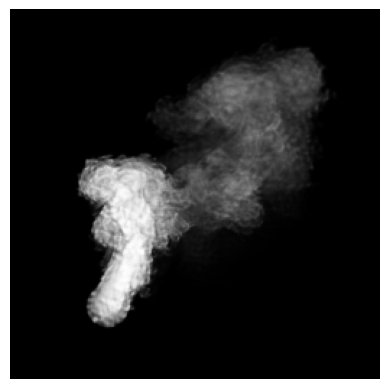

In [ ]:
renderer.render(canonical_cam, params["cam_fov"])

volume_render = torch.tensor(np.flipud(output_image.to_numpy()).copy(), requires_grad=True)
plt.imshow(volume_render.detach().numpy(), cmap="gray")
plt.axis("off")
plt.show()

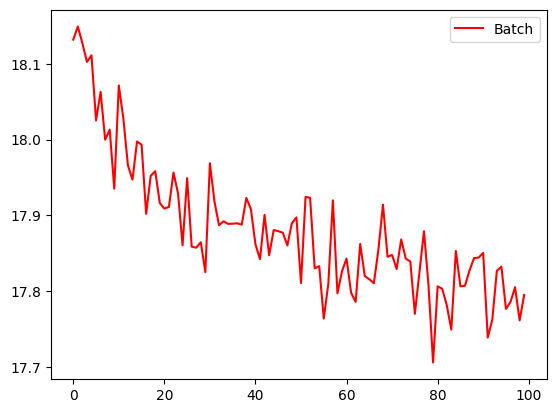

In [ ]:
x = range(len(batch_losses))
plt.plot(x, batch_losses, label="Batch", color="red")
# plt.yscale("log")
plt.legend()
plt.show()

torch.Size([256, 256])


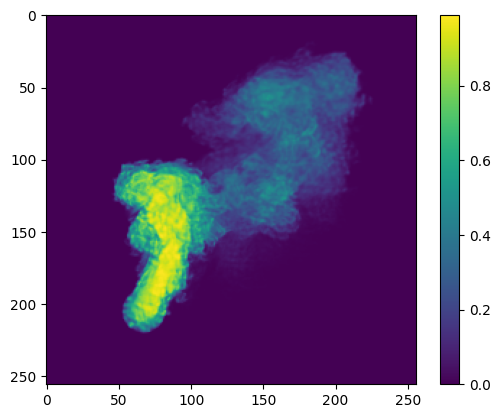

In [ ]:
from openvdb import FloatGrid, write as write_vdb
from pathlib import Path
from dataclasses import asdict
import time
import json

from cv2 import imwrite

out_root = Path("./vis4") / stylizer.__class__.__name__ / Path(sargs.style_path).stem
out_root.mkdir(parents=True, exist_ok=True)
curr_time = int(time.time())
vdb_name = f"{curr_time}_grid.vdb"
dump_name = f"{curr_time}_args.json"
image_name = f"{curr_time}_render.png"


out_grid = FloatGrid()
out_grid.name = "density"
out_np = (original_tensor * torch.exp(density_gain)).detach().numpy()
# out_np = (original_tensor * torch.exp(density_gain) * (original_tensor > 1e-2).type(torch.float32)).detach().numpy()
out_grid.copyFromArray(out_np, ijk=(0,0,0))
write_vdb(str(out_root / vdb_name), grids=[out_grid])

with open(out_root / dump_name, "w") as f:
    json.dump({
        "params": params, 
        "sargs": asdict(sargs),
        "losses": batch_losses,
    }, f)

print(volume_render.shape)
imwrite(
    out_root / image_name, 
    (volume_render
        .detach()
        .unsqueeze(2)
        .repeat((1,1,3))
        .numpy()
        * 255
    ).astype(np.uint8)
)
plt.imshow(volume_render.detach())
plt.colorbar()


In [ ]:
# from openvdb import FloatGrid
# from openvdb import write as write_vdb

# test_out_grid = FloatGrid()
# test_out_grid.name = "density"

# test_out_np = (original_tensor * density_gain).detach().numpy()
# test_out_grid.copyFromArray(test_out_np)
# write_vdb('test_out11.vdb', grids=[test_out_grid])